# Part 8: Workflow Integration — CI/CD & Automation

**vfairness.operations** — CI/CD and Monitoring

This notebook demonstrates the CI/CD integration capabilities of vfairness for automated bias prevention in ML pipelines.

The vfairness library is organized into eight parts following the ML fairness pipeline:
- **Part 1 — Data & Preprocessing** (`vfairness.preprocessing`) — Feature transforms, bias auditing
- **Part 2 — Training-Time Interventions** (`vfairness.in_processing`) — Losses, constraints, regularizers
- **Part 3 — Prediction-Time Interventions** (`vfairness.post_processing`) — Calibration, threshold tuning
- **Part 4 — Evaluation & Measurement** (`vfairness.evaluation`) — Metrics, statistics, visualization
- **Part 5 — Operations & Monitoring** (`vfairness.operations`) — MLOps, real-time monitoring, drift detection
- **Part 6 — Reporting & Dashboards** (`vfairness.operations.reporting`) — Interactive dashboards, automated reports
- **Part 7 — Experimentation** (`vfairness.operations.experimentation`) — A/B testing, Pareto & causal
- **Part 8 — Workflow Integration** (`vfairness.operations.cicd`) — CI/CD gates, pre-commit hooks, pytest plugin, report cards

> This notebook covers **Part 8** — CI/CD pipeline integration within `vfairness.operations`.

## Key Components

1. **DataBiasValidator** — Validates data pipelines for bias before model training
2. **ModelFairnessGate** — Deployment gates that enforce fairness requirements
3. **FairnessTestSuite** — pytest integration for test-driven bias prevention
4. **BiasMonitor** — Continuous monitoring with drift detection

See also [Part 5 — Monitoring Demo](vfairness_5_monitoring_demo.ipynb) for the monitoring infrastructure.

In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

# Import vfairness CI/CD components
from vfairness.operations.cicd import (
    DataBiasValidator,
    DataValidationConfig,
    ModelFairnessGate,
    GateConfig,
    FairnessTestSuite,
    BiasMonitor,
    MonitorConfig,
)

## 1. Generate Sample Data

We'll create a synthetic loan approval dataset with protected attributes.

In [2]:
np.random.seed(42)
n_samples = 2000

# Generate features
data = {
    'age': np.random.randint(18, 70, n_samples),
    'income': np.random.exponential(50000, n_samples),
    'credit_score': np.random.normal(650, 100, n_samples).clip(300, 850),
    'employment_years': np.random.exponential(5, n_samples),
    'debt_ratio': np.random.uniform(0, 1, n_samples),
}

# Protected attributes
data['gender'] = np.random.choice(['male', 'female'], n_samples, p=[0.55, 0.45])
data['race'] = np.random.choice(['white', 'black', 'asian', 'hispanic'], n_samples, p=[0.6, 0.15, 0.15, 0.1])

# Create outcome with some bias
base_prob = 0.3 + 0.3 * (data['credit_score'] > 650) + 0.2 * (data['income'] > 50000)
# Add bias based on protected attributes (this is what we want to detect!)
gender_bias = np.where(np.array(data['gender']) == 'male', 0.1, -0.05)
race_bias = np.where(np.array(data['race']) == 'white', 0.05, -0.03)
prob = (base_prob + gender_bias + race_bias).clip(0, 1)
data['approved'] = np.random.binomial(1, prob)

df = pd.DataFrame(data)
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (2000, 8)


,age,income,credit_score,employment_years,debt_ratio,gender,race,approved
0,56,79677.693684,588.210753,9.727944,0.519398,female,white,0
1,69,17418.899619,543.821895,8.494273,0.565033,female,hispanic,0
2,46,121427.847954,850.000000,2.974175,0.669684,male,asian,0
3,32,171343.091122,788.447244,3.359266,0.961382,male,white,1
4,60,10256.518036,645.779861,1.227896,0.602670,male,white,0


---

## 2. DataBiasValidator: Data Pipeline Validation

The `DataBiasValidator` checks your data for bias issues before model training begins. This is crucial for catching problems early in your pipeline.

In [3]:
# Create validator with custom thresholds
validator = DataBiasValidator(
    protected_attributes=['gender', 'race'],
    representation_thresholds={'min_group_fraction': 0.05, 'min_samples_per_group': 50},
    disparity_thresholds={'max_outcome_ratio': 1.5}
)

# Run validation
result = validator.validate(df, outcome_column='approved')

print(f"Validation Result: {result}")
print(f"\nSummary: {result.summary}")

Validation Result: DataValidationResult(PASSED, 0 errors, 0 warnings)

Summary: Validation passed - no bias issues detected


In [4]:
# Examine validation issues
if result.issues:
    print("Validation Issues Found:")
    print("=" * 50)
    for issue in result.issues:
        print(f"\n[{issue.severity.value.upper()}] {issue.issue_type}")
        print(f"  Message: {issue.message}")
        if issue.recommendation:
            print(f"  Recommendation: {issue.recommendation}")
else:
    print("No issues found!")

No issues found!


In [5]:
# View detailed metrics
print("Representation Metrics:")
for attr, metrics in result.metrics.get('representation', {}).items():
    print(f"\n  {attr}:")
    for group, fraction in metrics.get('fractions', {}).items():
        print(f"    {group}: {fraction:.1%}")

Representation Metrics:

  gender:
    male: 55.5%
    female: 44.5%

  race:
    white: 59.0%
    black: 16.0%
    asian: 15.3%
    hispanic: 9.8%


In [6]:
# Example: Integrate into a data pipeline
def load_and_validate_data(filepath_or_df, protected_attrs, outcome_col):
    """Example data loading function with built-in validation."""
    if isinstance(filepath_or_df, str):
        df = pd.read_csv(filepath_or_df)
    else:
        df = filepath_or_df
    
    validator = DataBiasValidator(
        protected_attributes=protected_attrs,
        disparity_thresholds={'max_outcome_ratio': 2.0}
    )
    
    result = validator.validate(df, outcome_column=outcome_col)
    
    if not result.passed:
        print(f"WARNING: Data validation failed!")
        print(f"Summary: {result.summary}")
        # In CI/CD, you might raise an exception here
        # raise ValueError(f"Data bias detected: {result.summary}")
    
    return df, result

# Use the function
validated_df, validation_result = load_and_validate_data(
    df, ['gender', 'race'], 'approved'
)

---

## 3. ModelFairnessGate: Deployment Gates

The `ModelFairnessGate` acts as a quality gate in your deployment pipeline, ensuring models meet fairness requirements before going to production.

In [7]:
# Prepare data for modeling
feature_cols = ['age', 'income', 'credit_score', 'employment_years', 'debt_ratio']
X = df[feature_cols]
y = df['approved']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Store protected attributes for test set
test_indices = X_test.index
gender_test = df.loc[test_indices, 'gender'].values

# Train a model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print(f"Model trained. Test accuracy: {(y_pred == y_test).mean():.3f}")

Model trained. Test accuracy: 0.628


In [8]:
# Create a fairness gate
gate = ModelFairnessGate(
    metrics=['demographic_parity_difference', 'equalized_odds_difference'],
    thresholds={
        'demographic_parity_difference': 0.1,
        'equalized_odds_difference': 0.15
    },
    require_improvement=False  # Set True to require improvement over baseline
)

# Convert gender to binary for metric computation
gender_binary = (gender_test == 'male').astype(int)

# Evaluate the model
decision = gate.evaluate(
    y_true=y_test.values,
    y_pred=y_pred,
    protected_attr=gender_binary,
    model_metadata={'model_type': 'RandomForest', 'version': '1.0'}
)

print(f"Gate Decision: {decision}")
print(f"\n{decision.summary}")

Gate Decision: GateDecision(approved, approved=True)

APPROVED - All fairness requirements met


In [9]:
# View detailed metric evaluations
print("Metric Evaluations:")
print("=" * 50)
for eval in decision.metric_evaluations:
    status = "PASS" if eval.passed else "FAIL"
    print(f"\n{eval.metric_name}:")
    print(f"  Value: {eval.value:.4f}")
    print(f"  Threshold: {eval.threshold:.4f}")
    print(f"  Status: {status}")

if decision.blocking_reasons:
    print("\nBlocking Reasons:")
    for reason in decision.blocking_reasons:
        print(f"  - {reason}")

Metric Evaluations:

demographic_parity_difference:
  Value: -0.0208
  Threshold: 0.1000
  Status: PASS

equalized_odds_difference:
  Value: -0.0125
  Threshold: 0.1500
  Status: PASS


In [10]:
# Generate a markdown report (useful for PR comments)
print(decision.to_markdown_report())

# Fairness Gate Decision Report

**Status**: APPROVED
**Timestamp**: 2026-02-11T17:15:26.798996

## Metric Evaluations

| Metric | Value | Threshold | Status |
|--------|-------|-----------|--------|
| demographic_parity_difference | -0.0208 | 0.1000 | ✅ Pass |
| equalized_odds_difference | -0.0125 | 0.1500 | ✅ Pass |


In [11]:
# Example: Deployment pipeline with fairness gate
def deploy_model(model, X_test, y_test, protected_attr):
    """Example deployment function with fairness gate."""
    y_pred = model.predict(X_test)
    
    gate = ModelFairnessGate(
        metrics=['demographic_parity_difference'],
        thresholds={'demographic_parity_difference': 0.1}
    )
    
    decision = gate.evaluate(y_test.values, y_pred, protected_attr)
    
    if decision.approved:
        print("Model APPROVED for deployment")
        # model.save() or deploy to production
        return True
    else:
        print("Model BLOCKED from deployment")
        print(f"Reasons: {decision.blocking_reasons}")
        return False

# Test deployment
deploy_model(model, X_test, y_test, gender_binary)

Model APPROVED for deployment


True

---

## 4. FairnessTestSuite: pytest Integration

The `FairnessTestSuite` enables test-driven bias prevention by integrating fairness checks into your test suite.

In [12]:
# Create a test suite
test_suite = FairnessTestSuite(
    protected_attributes=['gender'],
    metrics=['demographic_parity_difference', 'equalized_odds_difference'],
    thresholds={
        'demographic_parity_difference': 0.1,
        'equalized_odds_difference': 0.15
    }
)

# Prepare test data as DataFrame
test_df = X_test.copy()
test_df['approved'] = y_test
test_df['gender'] = gender_test

# Run tests (setting raise_on_failure=False to see all results)
results = test_suite.test_model(
    model=model,
    test_data=test_df,
    target_column='approved',
    raise_on_failure=False
)

print("Test Results:")
print("=" * 50)
for result in results:
    status_emoji = "✅" if result.passed else "❌"
    print(f"{status_emoji} {result.test_name}: {result.status.value}")
    if result.actual_value is not None:
        print(f"   Value: {result.actual_value:.4f}, Threshold: {result.threshold:.4f}")

Test Results:
✅ test_demographic_parity_difference_gender: passed
   Value: -0.0208, Threshold: 0.1000
✅ test_equalized_odds_difference_gender: passed
   Value: -0.0125, Threshold: 0.1500


In [13]:
# Get test summary
summary = test_suite.get_summary()
print(f"\nTest Summary:")
print(f"  Status: {summary['status']}")
print(f"  Total: {summary['total']}")
print(f"  Passed: {summary['passed']}")
print(f"  Failed: {summary['failed']}")


Test Summary:
  Status: passed
  Total: 2
  Passed: 2
  Failed: 0


In [14]:
# Export to JUnit XML format (for CI/CD integration)
junit_xml = test_suite.to_junit_xml()
print("JUnit XML Output:")
print(junit_xml)

JUnit XML Output:
<?xml version="1.0" encoding="UTF-8"?>
<testsuite name="FairnessTests" tests="2" failures="0" errors="0" skipped="0">
  <testcase name="test_demographic_parity_difference_gender" classname="FairnessTestSuite">
  </testcase>
  <testcase name="test_equalized_odds_difference_gender" classname="FairnessTestSuite">
  </testcase>
</testsuite>


In [15]:
# Example: Using assert_fairness in tests
from vfairness.operations.cicd.testing import assert_fairness, FairnessAssertionError

def test_model_demographic_parity():
    """Example test function using assert_fairness."""
    y_pred = model.predict(X_test)
    
    try:
        assert_fairness(
            y_true=y_test.values,
            y_pred=y_pred,
            protected_attr=gender_binary,
            metric='demographic_parity_difference',
            threshold=0.1,
            message="Model fails demographic parity requirement"
        )
        print("Test PASSED: Model meets demographic parity requirement")
    except FairnessAssertionError as e:
        print(f"Test FAILED: {e}")

test_model_demographic_parity()

Test PASSED: Model meets demographic parity requirement


---

## 5. BiasMonitor: Continuous Monitoring

The `BiasMonitor` provides continuous monitoring of fairness metrics in production, with drift detection and alerting capabilities.

In [16]:
# Establish baseline metrics from training/validation data
baseline_metrics = {
    'demographic_parity_difference': 0.05,  # Our target
    'equalized_odds_difference': 0.08
}

# Create alert callback
def alert_callback(alert):
    """Example alert handler - in production, send to Slack/PagerDuty/etc."""
    print(f"\n🚨 ALERT: {alert.message}")
    print(f"   Severity: {alert.severity.value}")
    print(f"   Metric: {alert.metric_name}")
    print(f"   Baseline: {alert.baseline_value:.4f}")
    print(f"   Current: {alert.current_value:.4f}")

# Create monitor
monitor = BiasMonitor(
    baseline_metrics=baseline_metrics,
    drift_threshold=0.05,
    window_size=5,
    alert_callback=alert_callback
)

print("BiasMonitor initialized with baseline metrics:")
for metric, value in baseline_metrics.items():
    print(f"  {metric}: {value}")

BiasMonitor initialized with baseline metrics:
  demographic_parity_difference: 0.05
  equalized_odds_difference: 0.08


In [17]:
# Simulate production monitoring with batches
print("Simulating production monitoring...")
print("=" * 50)

# Split test data into batches to simulate production
batch_size = 100
n_batches = len(X_test) // batch_size

for i in range(n_batches):
    start_idx = i * batch_size
    end_idx = start_idx + batch_size
    
    batch_X = X_test.iloc[start_idx:end_idx]
    batch_y = y_test.iloc[start_idx:end_idx].values
    batch_gender = gender_binary[start_idx:end_idx]
    
    # Get predictions (simulating production scoring)
    batch_pred = model.predict(batch_X)
    
    # Log batch to monitor
    result = monitor.log_batch(
        y_pred=batch_pred,
        y_true=batch_y,
        protected_attr=batch_gender,
        batch_id=f"batch_{i+1}"
    )
    
    # Print status
    status = "⚠️ DRIFT" if result.drift_detected else "✅ OK"
    print(f"Batch {i+1}: {status} | DPD: {result.metrics.get('demographic_parity_difference', 0):.4f}")

Simulating production monitoring...

🚨 ALERT: Fairness drift detected for demographic_parity_difference: baseline=0.0500, current=-0.1346, drift=0.1846
   Severity: critical
   Metric: demographic_parity_difference
   Baseline: 0.0500
   Current: -0.1346
Batch 1: ⚠️ DRIFT | DPD: -0.1346
Batch 2: ⚠️ DRIFT | DPD: -0.2167
Batch 3: ⚠️ DRIFT | DPD: 0.1108
Batch 4: ⚠️ DRIFT | DPD: -0.1355
Batch 5: ⚠️ DRIFT | DPD: 0.1181
Batch 6: ✅ OK | DPD: 0.0539


In [18]:
# Get monitoring summary
summary = monitor.get_summary()

print("\nMonitoring Summary:")
print("=" * 50)
print(f"Total batches: {summary['batch_count']}")
print(f"Total samples: {summary['total_samples']}")
print(f"Drift detected: {summary['drift_detected']}")
print(f"Total alerts: {summary['total_alerts']}")

print("\nCurrent Metrics:")
for metric, value in summary['current_metrics'].items():
    if value is not None:
        print(f"  {metric}: {value:.4f}")

print("\nRolling Average:")
for metric, value in summary['rolling_average'].items():
    if value is not None:
        print(f"  {metric}: {value:.4f}")


Monitoring Summary:
Total batches: 6
Total samples: 600
Drift detected: False
Total alerts: 1

Current Metrics:
  demographic_parity_difference: 0.0539

Rolling Average:
  demographic_parity_difference: -0.0139


In [19]:
# Check drift status
print("\nDrift Status by Metric:")
for metric, is_drifted in monitor.get_drift_status().items():
    status = "🟢 No drift" if not is_drifted else "🔴 DRIFT DETECTED"
    print(f"  {metric}: {status}")


Drift Status by Metric:
  demographic_parity_difference: 🟢 No drift


In [20]:
# Export Prometheus metrics (for monitoring dashboards)
prometheus_metrics = monitor.to_prometheus_metrics()
print("\nPrometheus Metrics:")
print(prometheus_metrics)


Prometheus Metrics:
fairness_demographic_parity_difference 0.05394524959742342
fairness_drift_demographic_parity_difference 0
fairness_monitor_batches_total 6
fairness_monitor_samples_total 600
fairness_monitor_alerts_total 1


---

## 6. CI/CD Pipeline Integration Example

Here's how you might integrate these components into a complete CI/CD pipeline.

In [21]:
def ml_pipeline_with_fairness_checks(
    data: pd.DataFrame,
    protected_attributes: list,
    target_column: str,
    feature_columns: list,
):
    """
    Example ML pipeline with integrated fairness checks.
    
    This demonstrates how to integrate vfairness CI/CD components
    into a typical ML training and deployment workflow.
    """
    print("\n" + "="*60)
    print("ML PIPELINE WITH FAIRNESS CHECKS")
    print("="*60)
    
    # =========================================
    # STEP 1: Data Validation
    # =========================================
    print("\n[STEP 1] Data Validation")
    print("-" * 40)
    
    validator = DataBiasValidator(
        protected_attributes=protected_attributes,
        disparity_thresholds={'max_outcome_ratio': 2.0}
    )
    
    validation_result = validator.validate(data, outcome_column=target_column)
    
    if not validation_result.passed:
        print(f"❌ Data validation FAILED: {validation_result.summary}")
        if validation_result.has_critical:
            raise ValueError("Critical data bias issues detected. Pipeline stopped.")
        print("⚠️ Proceeding with warnings...")
    else:
        print(f"✅ Data validation PASSED")
    
    # =========================================
    # STEP 2: Model Training
    # =========================================
    print("\n[STEP 2] Model Training")
    print("-" * 40)
    
    X = data[feature_columns]
    y = data[target_column]
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
    
    model = LogisticRegression(max_iter=1000, random_state=42)
    model.fit(X_train, y_train)
    
    accuracy = (model.predict(X_test) == y_test).mean()
    print(f"✅ Model trained. Test accuracy: {accuracy:.3f}")
    
    # =========================================
    # STEP 3: Fairness Testing
    # =========================================
    print("\n[STEP 3] Fairness Testing")
    print("-" * 40)
    
    test_suite = FairnessTestSuite(
        protected_attributes=protected_attributes,
        metrics=['demographic_parity_difference'],
        thresholds={'demographic_parity_difference': 0.1}
    )
    
    # Prepare test DataFrame
    test_df = X_test.copy()
    test_df[target_column] = y_test
    for attr in protected_attributes:
        test_df[attr] = data.loc[X_test.index, attr].values
    
    test_results = test_suite.test_model(
        model=model,
        test_data=test_df,
        target_column=target_column,
        raise_on_failure=False
    )
    
    test_summary = test_suite.get_summary()
    if test_summary['failed'] == 0:
        print(f"✅ All {test_summary['total']} fairness tests PASSED")
    else:
        print(f"❌ {test_summary['failed']}/{test_summary['total']} fairness tests FAILED")
    
    # =========================================
    # STEP 4: Deployment Gate
    # =========================================
    print("\n[STEP 4] Deployment Gate")
    print("-" * 40)
    
    gate = ModelFairnessGate(
        metrics=['demographic_parity_difference'],
        thresholds={'demographic_parity_difference': 0.1}
    )
    
    y_pred = model.predict(X_test)
    protected_values = (data.loc[X_test.index, protected_attributes[0]] == data[protected_attributes[0]].unique()[0]).astype(int).values
    
    decision = gate.evaluate(
        y_true=y_test.values,
        y_pred=y_pred,
        protected_attr=protected_values
    )
    
    if decision.approved:
        print(f"✅ Deployment APPROVED")
        print(f"   {decision.summary}")
    else:
        print(f"❌ Deployment BLOCKED")
        for reason in decision.blocking_reasons:
            print(f"   - {reason}")
    
    print("\n" + "="*60)
    print("PIPELINE COMPLETE")
    print("="*60)
    
    return {
        'model': model,
        'validation_result': validation_result,
        'test_results': test_results,
        'deployment_decision': decision
    }

In [22]:
# Run the complete pipeline
results = ml_pipeline_with_fairness_checks(
    data=df,
    protected_attributes=['gender'],
    target_column='approved',
    feature_columns=['age', 'income', 'credit_score', 'employment_years', 'debt_ratio']
)


ML PIPELINE WITH FAIRNESS CHECKS

[STEP 1] Data Validation
----------------------------------------
✅ Data validation PASSED

[STEP 2] Model Training
----------------------------------------
✅ Model trained. Test accuracy: 0.677

[STEP 3] Fairness Testing
----------------------------------------
✅ All 1 fairness tests PASSED

[STEP 4] Deployment Gate
----------------------------------------
✅ Deployment APPROVED
   APPROVED - All fairness requirements met

PIPELINE COMPLETE


### 📊 SVG Visual Dashboard

Generate an SVG CI/CD pipeline dashboard using the `vfairness.rendering` module:

SVG dashboard size: 4,967 bytes


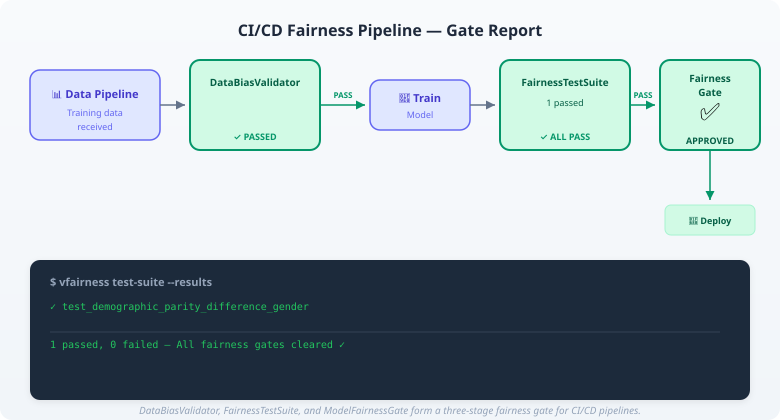

In [24]:
# Generate SVG CI/CD pipeline dashboard from the pipeline results
from IPython.display import SVG, display
from vfairness.rendering import cicd_pipeline_to_svg

svg_output = cicd_pipeline_to_svg(
    validation_result=results['validation_result'],
    test_results=results['test_results'],
    gate_decision=results['deployment_decision'],
)
print(f"SVG dashboard size: {len(svg_output):,} bytes")
display(SVG(data=svg_output))

---
## FairnessExplainer — Educational Explanations

The `FairnessExplainer` facade provides educational, context-aware explanations for any result object in the vfairness library. Both `DataBiasValidator` and `ModelFairnessGate` support `get_explanation()`.

In [ ]:
# FairnessExplainer — unified explanation facade
from vfairness.explainer import FairnessExplainer

# Explain the data validation result
val_explanation = validator.get_explanation(validation_result)
print(val_explanation)
print()

# Explain the gate decision
gate_explanation = gate.get_explanation(decision)
print(gate_explanation)

In [ ]:
# ── Validation · FairnessExplainer ───────────────────────────────────────────
from vfairness.explainer import FairnessExplainer, ExplanationReport

val_explanation = validator.get_explanation(validation_result)
gate_explanation = gate.get_explanation(decision)

assert isinstance(val_explanation, ExplanationReport)
assert isinstance(gate_explanation, ExplanationReport)
assert val_explanation.title == 'Data Validation Explanation'
assert gate_explanation.title == 'Fairness Gate Explanation'
assert FairnessExplainer.can_explain(validation_result) is True
assert FairnessExplainer.can_explain(decision) is True

print(f"✓ DataBiasValidator  | {val_explanation.severity} | {len(val_explanation.explanations)} explanation(s)")
print(f"✓ ModelFairnessGate  | {gate_explanation.severity} | {len(gate_explanation.explanations)} explanation(s)")

---

## Summary

The vfairness CI/CD module provides a comprehensive toolkit for integrating fairness checks into your ML pipelines:

1. **DataBiasValidator**: Catch bias issues early in your data pipeline
2. **ModelFairnessGate**: Enforce fairness requirements before deployment
3. **FairnessTestSuite**: Enable test-driven bias prevention with pytest
4. **BiasMonitor**: Continuously monitor production systems for fairness drift

These tools work together to create a comprehensive fairness-aware ML lifecycle.